## Final Project : Solving ODEs
### By : Rory Huck

In [10]:
# Imports 
import sympy as sp

# Defining the variable and funcation
x = sp.symbols('x')
y = sp.Function('y')

user_input = input("Enter the right side of dy/dx (in terms of x and y(x)): ")

rhs = sp.sympify(user_input)

# Define the differential equation
eq = sp.Eq(sp.diff(y(x), x), rhs)
#eq = sp.Eq(sp.diff(y(x), x), x*y(x))
#eq = sp.Eq(sp.diff(y(x), x), (x + 1)/y(x))
print("Equation:", sp.pprint(eq))

# Ideitifying type
eq_str = str(eq)
if "y(x)" in eq_str and "*" in eq_str:
    eq_type = "Separable"
elif "Derivative" in eq_str:
    eq_type = "First-order linear"
else:
    eq_type = "Unknown type"

print("Type:", eq_type)

# Solve
solution = sp.dsolve(eq)
print("Solution:", sp.pprint(solution))

Enter the right side of dy/dx (in terms of x and y(x)):  (x + 1)/y(x)


d          x + 1
──(y(x)) = ─────
dx         y(x) 
Equation: None
Type: First-order linear
⎡           _______________            _______________⎤
⎢          ╱       2                  ╱       2       ⎥
⎣y(x) = -╲╱  C₁ + x  + 2⋅x , y(x) = ╲╱  C₁ + x  + 2⋅x ⎦
Solution: None


In [34]:
import sympy as sp
sp.init_printing()
import matplotlib.pyplot as plt 

# Define variables
x = sp.symbols('x')
y = sp.Function('y')

# User input
user_input = input("Enter the right side of dy/dx: ")
rhs = sp.sympify(user_input)

# Define equation
eq = sp.Eq(sp.diff(y(x), x), rhs)

print("\n Differential Equation:")
display(eq) 

eq_str = str(rhs)
if "y(x)" in eq_str and "/" in eq_str:
    eq_type = "Separable"
elif "y(x)" in eq_str:
    eq_type = "First-order linear"
else:
    eq_type = "Unknown type"

print("\nType:", eq_type)

# Solve
solution = sp.dsolve(eq)

print("\n Solution:") 
display(solution)

Enter the right side of dy/dx:  (x + 1)/y(x)



 Differential Equation:



Type: Separable

 Solution:


### Instructions for the ODE solver code below:
####     To use this ODE classifier and solver users will be asked to enter the Right-Hand side of the differential equation they are trying to solve. It must be in the form dy/dx = F(x,y(x)). Python style syntax is required for the tool to understand your ODE. This program treats y as a function so when entering the varible of your it must be entered as y(x). After you have entered your equation the program will ask if you have intial conditions you would like to enter. If yes, you will enter the x-value and then the y-value. This will give the particular solution instead of the general. The progam will then solve and classify your ODE and displau the final solution as well as a graph and slope field to help you visualize your equations behavior. 
####     For example to input the equation dy/dx = x*y(x) I would type x*y(x) using * for multiplication, ** for powers, and exp(x) for expontentials. For my Initial conditions x0=0 and y(x0)=1 I would type 0 and 1 into the prompted inputs. 

#### List of ODEs to Try: 
Separable ODEs:
- x*y(x)
- y(x)/x
- sin(x)y(x)
- (x**2)(y(x)**2)

Separable with initial conditions:
- x*y(x), x0=0, y0=1
- y(x)/x, x0=1, y0=2
- sin(x)y(x), x0=0, y0=1
- (x**2)(y(x)**2), x0=0, y0=1

Linear ODEs:
- x + y(x)
- 2*y(x) + x
- y(x) - x
- exp(x)*y(x)

Linear with initial conditions:
- x + y(x), x0=0, y0=1
- y(x) - x, x0=0, y0=2
- 2*y(x) + x, x0=0, y0=1
- exp(x)*y(x), x0=0, y0=1

Slope field examples:
- x + y(x)
- y(x) - x
- x - y(x)
- sin(x) - y(x)

Slope field with initial conditions:
- x - y(x), x0=0, y0=1
- sin(x) - y(x), x0=0, y0=0

Tricky test cases:
- (y(x) + 1)/x
- (x + y(x))/x
- y(x)**2 + x
- exp(x + y(x))

Tricky with initial conditions:
- (y(x) + 1)/x, x0=1, y0=1
- y(x)**2 + x, x0=0, y0=1

Edge cases:
- 1/x
- y(x)/x, x0=0
- log(x)*y(x)

Best demo examples:
- sin(x)*y(x), x0=0, y0=1
- x - y(x), x0=0, y0=1
-(y(x)+1)/x, x0=1, y0=1

In [43]:
# Imports
import sympy as sp
sp.init_printing()
import numpy as np
import matplotlib.pyplot as plt

In [46]:
#Updated code
# Define variables
x = sp.symbols('x')
y = sp.Function('y')

def classify_ode(rhs):
    try:
        if sp.separatevars(rhs, symbols=[x, y(x)]):
            return "Separable"
    except:
        pass
    
    if rhs.has(y(x)):
        return "First-order linear (likely)"
    
    return "Unknown"


def solve_with_steps(rhs, ics=None):
    eq = sp.Eq(sp.diff(y(x), x), rhs)
    
    print("\nDifferential Equation:")
    display(eq)
    
    ode_type = classify_ode(rhs)
    print("\nType:", ode_type)
    
    # Step-by-step (separable only)
    if ode_type == "Separable":
        print("\nStep-by-step solution:")
        
        Y = sp.symbols('Y')
        rhs_temp = rhs.subs(y(x), Y)
        
        separated = sp.separatevars(rhs_temp, symbols=[x, Y], dict=True)
        
        if separated:
            f_x = separated[x]
            g_y = separated[Y]
            
            print("1) Separate variables:")
            display(sp.Eq(1/g_y * sp.diff(y(x), x), f_x))
            
            print("2) Integrate both sides:")
            left = sp.integrate(1/g_y, y(x))
            right = sp.integrate(f_x, x)
            display(sp.Eq(left, right))
        else:
            print("Could not separate variables.")
    
    # Solve
    if ics:
        solution = sp.dsolve(eq, ics=ics)
    else:
        solution = sp.dsolve(eq)
    
    print("\nFinal Solution:")
    display(solution)
    
    return solution, eq


def plot_solution(solution):
    try:
        sol_expr = solution.rhs
        f = sp.lambdify(x, sol_expr, 'numpy')

        x_vals = np.linspace(-5, 5, 200)
        y_vals = f(x_vals)

        plt.figure()
        plt.plot(x_vals, y_vals)
        plt.title("Solution Curve")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.grid()
        plt.show()
    except:
        print("Could not plot solution.")


def slope_field(rhs):
    try:
        f = sp.lambdify((x, y(x)), rhs, 'numpy')

        X, Y = np.meshgrid(np.linspace(-5,5,20), np.linspace(-5,5,20))
        U = np.ones_like(X)
        V = f(X, Y)

        plt.figure()
        plt.quiver(X, Y, U, V)
        plt.title("Slope Field")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.show()
    except:
        print("Could not generate slope field.")

In [47]:
# user input
user_input = input("Enter dy/dx = ")
rhs = sp.sympify(user_input)

# initial condition
use_ic = input("Do you want to enter an initial condition? (y/n): ")

ics = None
if use_ic.lower() == 'y':
    x0 = float(input("Enter x0: "))
    y0 = float(input("Enter y(x0): "))
    ics = {y(x0): y0}

# SOLVE FIRST (IMPORTANT ORDER)
solution, eq = solve_with_steps(rhs, ics)

Enter dy/dx =  x*y(x)
Do you want to enter an initial condition? (y/n):  n



Differential Equation:



Type: Separable

Step-by-step solution:
1) Separate variables:


2) Integrate both sides:



Final Solution:


Could not plot solution.


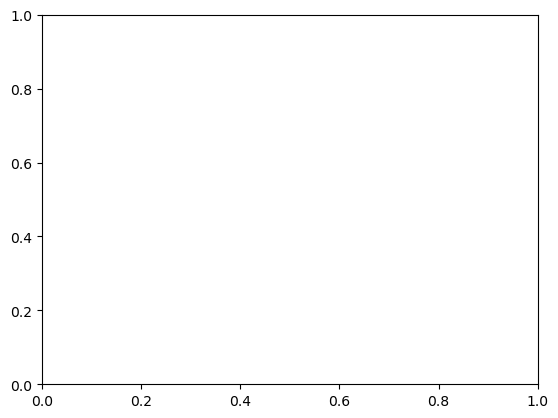

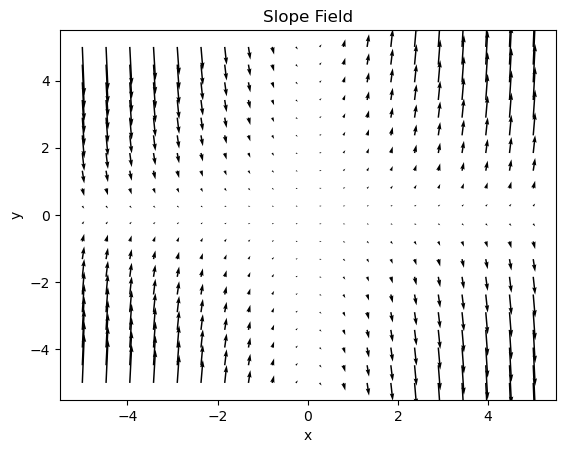

In [48]:
# plots AFTER solution is printed
plot_solution(solution)
slope_field(rhs)